In [1]:
import numpy as np
import importlib
import matplotlib.pyplot as plt

import modules.constants
import modules.utils
import modules.loaddata
import modules.interpolation_preprocess
def reload_modules():
    importlib.reload(modules.constants)
    importlib.reload(modules.utils)
    importlib.reload(modules.loaddata)
    importlib.reload(modules.interpolation_preprocess)

In [7]:
reload_modules()
q, data = modules.loaddata.load_response_functions("../week4/results/", "responses_C12_CC_LFG")
data.shape

(103, 5, 2, 51)

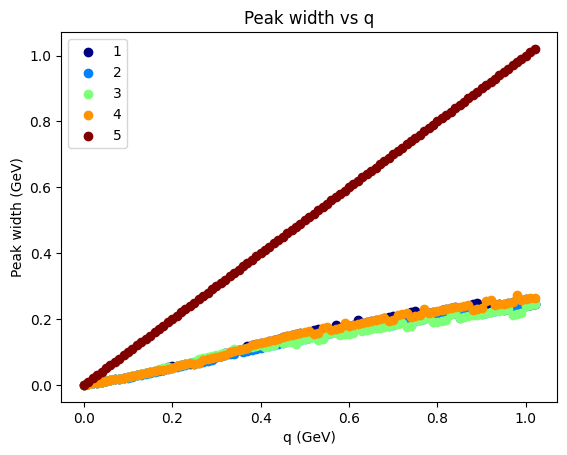

a
a
a
a
a


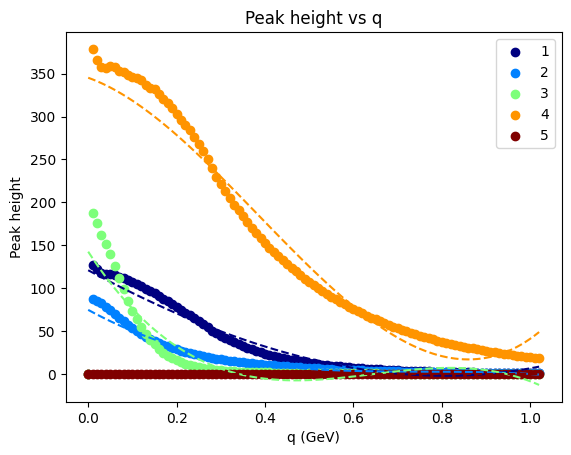

In [13]:
importlib.reload(modules.interpolation_preprocess)

widths = [[] for _ in range(5)]
heights = [[] for _ in range(5)]
for (qval, dval) in zip(q, data):
    for (curve_n, curve) in enumerate(dval):
        # plt.plot(dval[:,0], dval[:,curve], label=f"q={qval:.2f} GeV, curve={curve}")
        width = modules.interpolation_preprocess.get_peak_width(curve[0], curve[1])
        widths[curve_n].append(width)
        heights[curve_n].append(np.max(curve[1]))

widths = np.array(widths)
heights = np.array(heights)

colors = modules.utils.generate_colourscale(len(widths))
for i, width in enumerate(widths):
    plt.scatter(q, width, color=colors[i], label=f"{i+1}")

plt.xlabel("q (GeV)")
plt.ylabel("Peak width (GeV)")
plt.legend()
plt.title("Peak width vs q")
plt.show()

for i, height in enumerate(heights):
    print("a")
    plt.scatter(q, height, color=colors[i], label=f"{i+1}")
    fit = np.polyfit(q, height, deg=3)
    qsorted = np.sort(q)
    plt.plot(qsorted, np.poly1d(fit)(qsorted), color=colors[i], linestyle="--")
plt.xlabel("q (GeV)")
plt.ylabel("Peak height")
plt.legend()
plt.title("Peak height vs q")
plt.show()

/mnt/bogdisk/_/plugg/kandidat/neutrino_bsc_26/modules/utils.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(gaussian, x, y, p0=initial_guess)


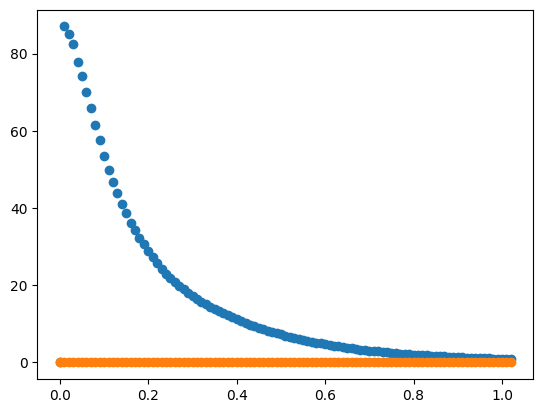

In [15]:
reload_modules()

#dimensions: q, w, curve

idx = 1

widths, heights = modules.interpolation_preprocess.extract_interp_param_curves(q, data[:, idx, 0], data[:, idx, 1])
plt.scatter(q, heights)

params = modules.utils.gaussian_fit(q, heights)
plt.scatter(q, modules.utils.gaussian(q, *params), label="Gaussian fit")

/mnt/bogdisk/_/plugg/kandidat/neutrino_bsc_26/modules/utils.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(gaussian, x, y, p0=initial_guess)


(0.0, 0.08)

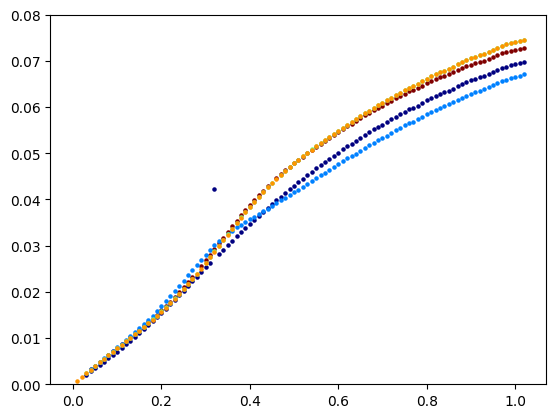

In [25]:
reload_modules()

#dimensions: q, w, curve

idx = 1

colors = modules.utils.generate_colourscale(5)

widths_per_curve = []
heights_per_curve = []

for idx in range(len(data[0])):
    widths, heights = modules.interpolation_preprocess.extract_interp_param_curves(q, data[:,idx,0], data[:,idx,1])
    plt.scatter(q, np.abs(widths), color=colors[idx-1], label=f"Curve {idx}", s=5)
    widths_per_curve.append(widths)
    heights_per_curve.append(heights)

ysize = 0.08
plt.ylim(0, ysize)

    # params = modules.utils.gaussian_fit(q, heights)
    # plt.scatter(q, modules.utils.gaussian(q, *params), label="Gaussian fit")

/tmp/ipykernel_77406/3617689557.py:15: RuntimeWarning: invalid value encountered in divide
  yvals = yvals / estimated_height


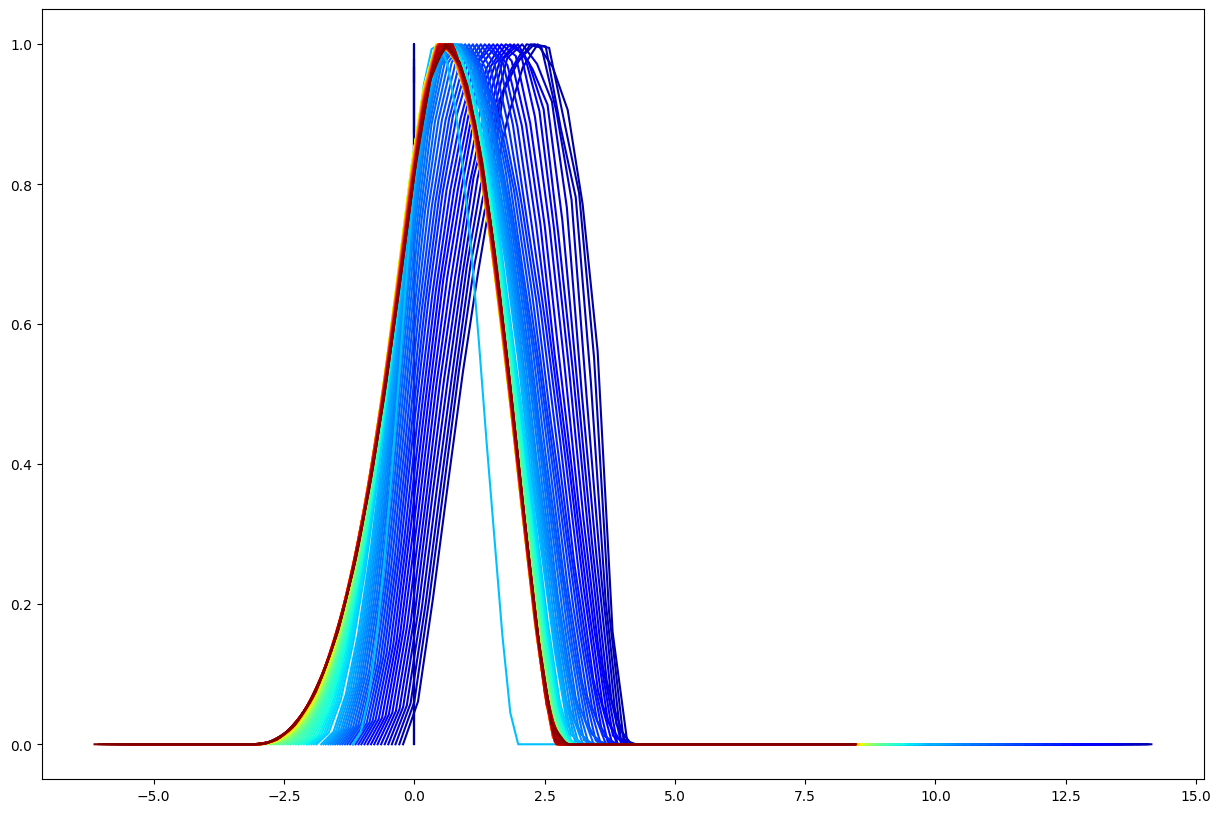

In [45]:
reload_modules()
idx= 1
colors = modules.utils.generate_colourscale(len(q))
plt.figure(figsize=(15,10))

(q, widths_per_curve, heights_per_curve) = modules.interpolation_preprocess.get_transform_params(q, data)

for (i, (qval, wvals, yvals)) in enumerate(zip(q, data[:, idx, 0], data[:, idx, 1])):
    estimated_width = np.abs(np.interp(qval, q, widths_per_curve[idx]))
    estimated_height = np.interp(qval, q, heights_per_curve[idx])

    wpeak = modules.utils.peak(qval, 1)
    wvals = wvals - wpeak
    wvals = wvals/estimated_width
    yvals = yvals / estimated_height

    

    # plt.scatter(qval, np.abs(estimated_width), color="red", label="Estimated width")
    # print(qval, estimated_width)

    plt.plot(wvals, yvals, color=colors[i])
    # 
# plt.ylim(0, 0.08)

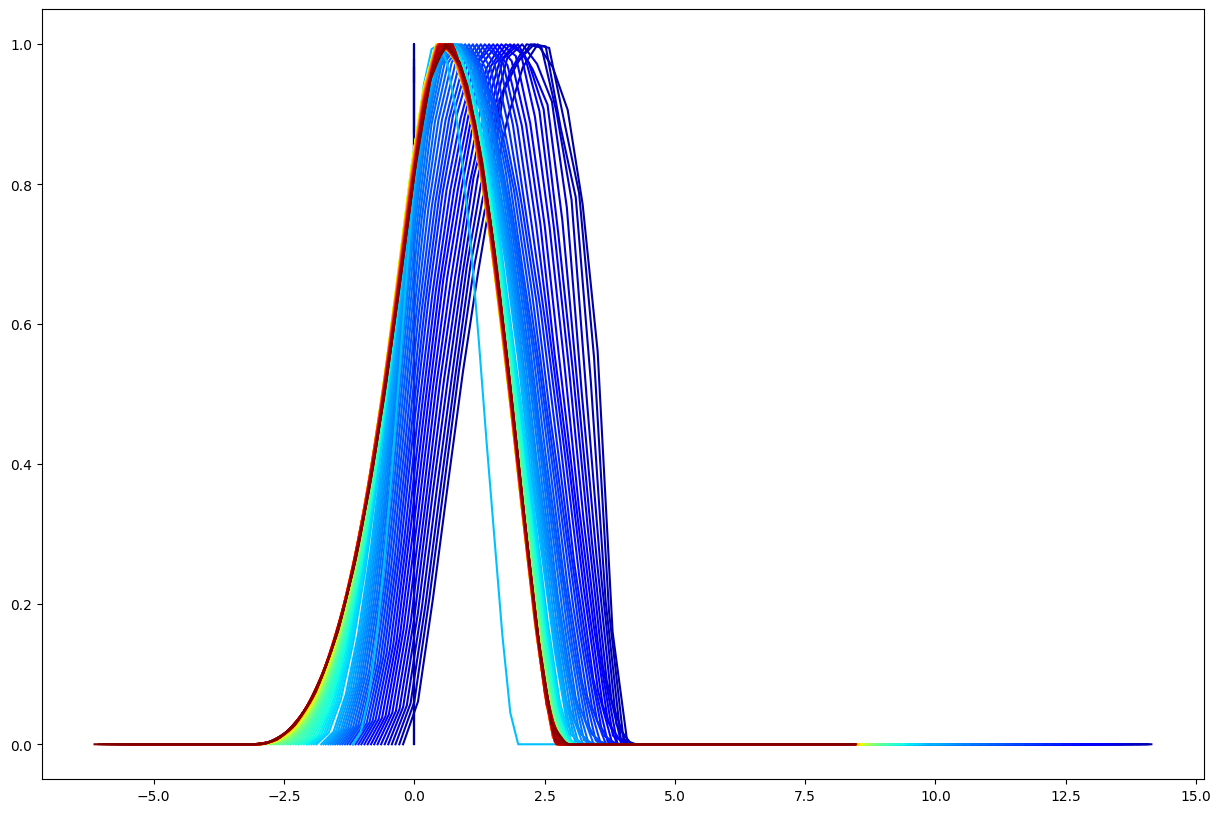

In [49]:
# How to use
reload_modules()
q, data = modules.loaddata.load_response_functions("../week4/results/", "responses_C12_CC_LFG")
transform_params = modules.interpolation_preprocess.get_transform_params(q, data)
data_transformed = modules.interpolation_preprocess.transform_data(q, data, transform_params)

plt.figure(figsize=(15,10))

colors = modules.utils.generate_colourscale(len(q))
for idx in range(1,2):
    for i, qval in enumerate(q):
        wvals = data_transformed[i,idx,0]
        yvals = data_transformed[i,idx,1]
        plt.plot(wvals, yvals, color=colors[i])

In [ ]:
reload_modules()
(ab_initio_qvals, ab_initio_data) = modules.loaddata.load_ab_initio("./data/ab_initio_nu_responses/")

(8, 2, 4001)